# Model 3 CNN for Swahili News Classification

**Owner:** Alain  |  **Model:** `cnn`

One-dimensional CNN over word embeddings (Kim, 2014). All experiments are coded in section 3f and run automatically; every run is logged to `results/experiment_logs/`.

| # | experiment_name | Question it answers |
|---|---|---|
| 1 | `baseline_random` | Baseline CNN with random embeddings, filter sizes 3, 4, 5 |
| 2 | `fasttext` | Do pretrained Swahili fastText vectors help with only ~3,600 articles? (Kastanos and Martin, 2021) |
| 3 | `max_len_150` / `max_len_400` | How much of each article does the CNN need? (Median ≈ 270 words) |
| 4 | `class_weights` | Does weighting help the rare classes? |

**Rules for fair comparison:** train on `train`, tune on `validation`, touch `test` once at the end; log everything.

## 1. Setup

In [1]:
MEMBER = "Alain"
MODEL_NAME = "cnn"

In [2]:
# Cloning the repository
import os
import sys
from pathlib import Path

COLAB = "google.colab" in sys.modules

if COLAB:
    !git clone https://github.com/michael-alu/nlp_language_technologies.git
    %cd nlp_language_technologies
    %pip install -q -r requirements.txt

if Path.cwd().name == "notebooks":
    os.chdir("..")

sys.path.append(os.getcwd())
print("Working directory:", os.getcwd())

Cloning into 'nlp_language_technologies'...
remote: Enumerating objects: 255, done.
remote: Counting objects: 100% (255/255), done.
remote: Compressing objects: 100% (167/167), done.
remote: Total 255 (delta 106), reused 216 (delta 72), pack-reused 0 (from 0)
Receiving objects: 100% (255/255), 9.70 MiB | 22.63 MiB/s, done.
Resolving deltas: 100% (106/106), done.
/content/nlp_language_technologies
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 73.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 947.5/947.5 kB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.2/60.2 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 125.5 MB/s eta 0:00:00
Working directory: /content/nlp_language_technologies


In [4]:
#fetching the dependencies
import re
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import DataLoader, Dataset

from src import calibration
from src import config
from src import data_loading
from src import evaluation
from src import plots
from src.experiment_log import log_experiment
from src.reproducibility import FINAL_RUN_SEEDS, set_seed

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## 2. Load the data

In [6]:
# Loading train, test and validation data
train = data_loading.load_train()
validation = data_loading.load_validation()
test = data_loading.load_test()
zindi_test = data_loading.load_zindi_test()

train_ids = np.asarray(data_loading.labels_to_ids(train["category"]))
validation_ids = np.asarray(data_loading.labels_to_ids(validation["category"]))
test_ids = np.asarray(data_loading.labels_to_ids(test["category"]))

print("Labels in order:", config.LABELS)
print("Sizes:",
      len(train), "for train|",
      len(validation), "for validation|",
      len(test), "for test")

Labels in order: ['kitaifa', 'michezo', 'biashara', 'kimataifa', 'burudani']
Sizes: 3603 for train| 772 for validation| 773 for test


## 3. Build and train the model

### 3a. Tokenizer and vocabulary

identical code in both notebooks. Vocabulary built from the training split only.

In [7]:
PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"
MIN_FREQ = 2  # words seen once become <unk>


def tokenize(text):
    return re.findall(r"[\w']+", str(text).lower(), flags=re.UNICODE)


def build_vocabulary(texts, min_freq=MIN_FREQ):
    counts = Counter()
    for text in texts:
        counts.update(tokenize(text))
    vocab = {PAD_TOKEN: 0, UNK_TOKEN: 1}
    for word, n in sorted(counts.items()):
        if n >= min_freq:
            vocab[word] = len(vocab)
    return vocab


def encode(text, vocab, max_len):
    ids = [vocab.get(w, vocab[UNK_TOKEN]) for w in tokenize(text)[:max_len]]
    ids += [vocab[PAD_TOKEN]] * (max_len - len(ids))
    return ids


vocab = build_vocabulary(train["content"])
print("Vocabulary size:", len(vocab))

Vocabulary size: 28139


### 3b. Default settings

Experiments override these; every override is stored in the log row, so each row shows exactly what was run.

In [8]:
BASE_SETTINGS = {
    "embedding": "random", # "random" | "fasttext"
    "max_len": 300,   # median article is ~270 words
    "class_weights": False,
    "filter_sizes": [3, 4, 5],
    "num_filters": 100,
    "embedding_dim": 300,
    "dropout": 0.5,
    "epochs": 30,
    "batch_size": 64,
    "lr": 1e-3,
    "patience": 4, # early stopping
}

current_settings = dict(BASE_SETTINGS)

### 3c. Embedding matrix (random or pretrained fastText)

For the fastText experiments, download the Swahili vectors first

Words not covered by fastText keep a random vector; `<pad>` stays zero.

In [9]:
!wget -q https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.sw.300.vec.gz
!gunzip -k cc.sw.300.vec.gz

In [10]:
FASTTEXT_PATH = "cc.sw.300.vec"
_fasttext_cache = {}

# loading the vectors
def load_fasttext_vectors(vocab, path, dim):
    if dim not in _fasttext_cache:
        raw = {}
        with open(path, encoding="utf-8", errors="ignore") as f:
            next(f)  # header line
            for line in f:
                parts = line.rstrip().split(" ")
                if len(parts[1:]) == dim:
                    raw[parts[0]] = np.asarray(parts[1:], dtype=np.float32)
        _fasttext_cache[dim] = raw
    raw = _fasttext_cache[dim]
    return {w: raw[w] for w in vocab if w in raw}

# embedding matrix
def build_embedding_matrix(vocab, settings):
    dim = settings["embedding_dim"]
    scale = 1.0 / np.sqrt(dim)
    matrix = np.random.uniform(-scale, scale, size=(len(vocab), dim)).astype(np.float32)
    matrix[vocab[PAD_TOKEN]] = 0.0
    if settings["embedding"] == "fasttext":
        pretrained = load_fasttext_vectors(vocab, FASTTEXT_PATH, dim)
        for word, vec in pretrained.items():
            matrix[vocab[word]] = vec
        print(f"fastText coverage: {len(pretrained)}/{len(vocab)} words "
              f"({100 * len(pretrained) / len(vocab):.1f}%)")
    return matrix

### 3d. Dataset and model

Embedding -> parallel Conv1d (filter sizes 3, 4, 5) -> max-over-time pooling -> dropout -> linear -> **logits**. Softmax is applied only when probabilities are needed; the raw logits are kept for temperature scaling.

In [11]:
class NewsDataset(Dataset):
    def __init__(self, texts, targets=None):
        self.texts = list(texts)
        self.targets = None if targets is None else np.asarray(targets)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, i):
        x = torch.tensor(encode(self.texts[i], vocab, current_settings["max_len"]),
                         dtype=torch.long)
        if self.targets is None:
            return x
        return x, torch.tensor(self.targets[i], dtype=torch.long)


class TextCNN(nn.Module):
    def __init__(self, embedding_matrix, filter_sizes, num_filters, num_classes, dropout):
        super().__init__()
        dim = embedding_matrix.shape[1]
        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(embedding_matrix), freeze=False, padding_idx=0
        )
        self.convs = nn.ModuleList(
            [nn.Conv1d(dim, num_filters, kernel_size=k, padding=k // 2) for k in filter_sizes]
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(filter_sizes), num_classes)

    def forward(self, x):
        emb = self.embedding(x).transpose(1, 2)  # (batch, dim, seq_len)
        pooled = [torch.relu(conv(emb)).amax(dim=2) for conv in self.convs]
        features = torch.cat(pooled, dim=1)
        return self.fc(self.dropout(features)) # logits


def build_model(embedding_matrix, settings):
    return TextCNN(
        embedding_matrix=embedding_matrix,
        filter_sizes=settings["filter_sizes"],
        num_filters=settings["num_filters"],
        num_classes=len(config.LABELS),
        dropout=settings["dropout"],
    ).to(device)

### 3e. Training loop

- Early stopping on **validation loss** (`patience` epochs), restoring the best epoch.
- Records `train_loss`, `validation_loss`, `validation_macro_f1` per epoch.
- Optional balanced class weights for the rare classes.
- Returns the trained model, the history, and the **validation logits** for calibration.

In [12]:
@torch.no_grad()
def predict_logits(model, texts):
    model.eval()
    loader = DataLoader(NewsDataset(texts), batch_size=256)
    return torch.cat([model(x.to(device)) for x in loader]).cpu().numpy()


def make_criterion(settings):
    if settings["class_weights"]:
        weights = compute_class_weight(
            "balanced", classes=np.arange(len(config.LABELS)), y=train_ids
        )
        return nn.CrossEntropyLoss(
            weight=torch.tensor(weights, dtype=torch.float32, device=device))
    return nn.CrossEntropyLoss()


def train_model(settings, seed=config.RANDOM_SEED, verbose=True):
    global current_settings
    current_settings = dict(settings)
    set_seed(seed)

    embedding_matrix = build_embedding_matrix(vocab, settings)
    model = build_model(embedding_matrix, settings)
    optimizer = torch.optim.Adam(model.parameters(), lr=settings["lr"])
    criterion = make_criterion(settings)

    train_loader = DataLoader(
        NewsDataset(train["content"], train_ids),
        batch_size=settings["batch_size"], shuffle=True,
    )
    val_ds = NewsDataset(validation["content"])
    val_inputs = torch.stack([val_ds[i] for i in range(len(val_ds))]).to(device)
    val_targets = torch.tensor(validation_ids, device=device)

    history = {"train_loss": [], "validation_loss": [], "validation_macro_f1": []}
    best_state, best_val_loss, epochs_without_improvement = None, float("inf"), 0

    for epoch in range(1, settings["epochs"] + 1):
        model.train()
        total_loss = 0.0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(y)

        model.eval()
        with torch.no_grad():
            val_logits = model(val_inputs)
            val_loss = criterion(val_logits, val_targets).item()
            val_macro_f1 = f1_score(validation_ids, val_logits.argmax(1).cpu(),
                                    average="macro", zero_division=0)

        history["train_loss"].append(total_loss / len(train))
        history["validation_loss"].append(val_loss)
        history["validation_macro_f1"].append(val_macro_f1)
        if verbose:
            print(f"epoch {epoch:02d} | train_loss {history['train_loss'][-1]:.4f} "
                  f"| val_loss {val_loss:.4f} | val_macro_f1 {val_macro_f1:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= settings["patience"]:
                if verbose:
                    print(f"Early stopping at epoch {epoch}")
                break

    model.load_state_dict(best_state)
    validation_logits = predict_logits(model, validation["content"])
    return model, history, validation_logits

### 3f. Run all experiments

`run_experiment` trains, calibrates, evaluates and logs one experiment — **scores before and after temperature scaling are both logged**. Running the cell below runs the full experiment plan; results are collected in `experiment_results`.

Experiment 2 needs `cc.sw.300.vec` (see 3c). If it is missing, that experiment is skipped with a warning instead of crashing the run.

In [13]:
def softmax(logits):
    return torch.softmax(torch.tensor(logits), dim=1).numpy()


def run_experiment(experiment_name, overrides, notes, seed=config.RANDOM_SEED):
    settings = {**BASE_SETTINGS, **overrides}

    if settings["embedding"] == "fasttext" and not Path(FASTTEXT_PATH).exists():
        print(f"SKIP {experiment_name}: {FASTTEXT_PATH} not found (see section 3c)")
        return None

    print(f"\n=== {experiment_name} ===")
    print("overrides:", overrides)
    model, history, validation_logits = train_model(settings, seed=seed)

    #before calibration
    validation_probabilities = softmax(validation_logits)
    scores = evaluation.compute_scores(validation_ids, validation_probabilities)
    log_experiment(MEMBER, MODEL_NAME, experiment_name, "validation",
                   settings, scores, notes)

    #after temperature scaling (Guo et al., 2017)
    temperature = calibration.find_best_temperature(validation_logits, validation_ids)
    calibrated = calibration.softmax(validation_logits, temperature)
    cal_scores = evaluation.compute_scores(validation_ids, calibrated)
    log_experiment(MEMBER, MODEL_NAME, experiment_name + "_calibrated", "validation",
                   {**settings, "temperature": temperature}, cal_scores,
                   notes + " | after temperature scaling")

    print(f"macro-F1 {scores['macro_f1']:.4f} -> {cal_scores['macro_f1']:.4f} | "
          f"log loss {scores['log_loss']:.4f} -> {cal_scores['log_loss']:.4f} | "
          f"T={temperature:.3f}")

    return {"experiment_name": experiment_name, "settings": settings, "model": model,
            "history": history, "validation_logits": validation_logits,
            "temperature": temperature, "scores": scores, "calibrated_scores": cal_scores}


EXPERIMENTS = [
    ("baseline_random", {},
     "Experiment 1: random embeddings, filter sizes 3/4/5, max_len 300, no class weights"),
    ("fasttext", {"embedding": "fasttext"},
     "Experiment 2: pretrained Swahili fastText vectors. Hypothesis: they do not help on "
     "this small dataset (Kastanos and Martin, 2021)"),
    ("max_len_150", {"max_len": 150},
     "Experiment 3a: shorter cap, below the median of ~270 words"),
    ("max_len_400", {"max_len": 400},
     "Experiment 3b: longer cap, above the median"),
    ("class_weights", {"class_weights": True},
     "Experiment 4: balanced class weights to help kimataifa and burudani"),
]

experiment_results = {}
for name, overrides, notes in EXPERIMENTS:
    result = run_experiment(name, overrides, notes)
    if result is not None:
        experiment_results[name] = result


=== baseline_random ===
overrides: {}
Random seed set to 42
epoch 01 | train_loss 1.0905 | val_loss 0.7091 | val_macro_f1 0.3197
epoch 02 | train_loss 0.5741 | val_loss 0.4665 | val_macro_f1 0.5053
epoch 03 | train_loss 0.3957 | val_loss 0.4071 | val_macro_f1 0.5039
epoch 04 | train_loss 0.2896 | val_loss 0.3871 | val_macro_f1 0.5150
epoch 05 | train_loss 0.1810 | val_loss 0.3940 | val_macro_f1 0.5222
epoch 06 | train_loss 0.1059 | val_loss 0.4242 | val_macro_f1 0.5157
epoch 07 | train_loss 0.0657 | val_loss 0.4516 | val_macro_f1 0.5196
epoch 08 | train_loss 0.0401 | val_loss 0.4877 | val_macro_f1 0.5187
Early stopping at epoch 8
Logged experiment 'baseline_random' to /content/nlp_language_technologies/results/experiment_logs/cnn.csv
Best temperature: 1.10 (validation log loss 0.3848)
Logged experiment 'baseline_random_calibrated' to /content/nlp_language_technologies/results/experiment_logs/cnn.csv
macro-F1 0.5150 -> 0.5150 | log loss 0.3871 -> 0.3848 | T=1.100

=== fasttext ===
over

### 3g. Compare the experiments

Validation macro-F1 and log loss for every run (calibrated). Pick the final settings for section 5 from this table.

In [14]:
comparison = pd.DataFrame([
    {"experiment": name,
     "macro_f1": r["calibrated_scores"]["macro_f1"],
     "log_loss": r["calibrated_scores"]["log_loss"],
     "accuracy": r["calibrated_scores"]["accuracy"]}
    for name, r in experiment_results.items()
]).sort_values("macro_f1", ascending=False)

comparison

,experiment,macro_f1,log_loss,accuracy
4,class_weights,0.6087,0.4343,0.8264
1,fasttext,0.5209,0.3909,0.8653
2,max_len_150,0.5192,0.3837,0.8627
3,max_len_400,0.5161,0.3836,0.8575
0,baseline_random,0.5150,0.3848,0.8562


## 4. Study the best experiment

We set `best_name` to the winner from the comparison table, then run the cells below for the full validation evaluation: classification report, confusion matrix, ROC curves and learning curves.

In [15]:
best_name = "class_weights"  # changed to the winner from the table above
best = experiment_results[best_name]

calibrated_validation_probabilities = calibration.softmax(
    best["validation_logits"], best["temperature"])

evaluation.print_classification_report(validation_ids, calibrated_validation_probabilities)
best["calibrated_scores"]

              precision    recall  f1-score   support

     kitaifa       0.78      0.80      0.79       300
     michezo       0.94      0.94      0.94       258
    biashara       0.78      0.74      0.76       204
   kimataifa       0.50      0.62      0.56         8
    burudani       0.00      0.00      0.00         2

    accuracy                           0.83       772
   macro avg       0.60      0.62      0.61       772
weighted avg       0.83      0.83      0.83       772



{'accuracy': 0.8264,
 'log_loss': 0.4343,
 'macro_f1': 0.6087,
 'weighted_f1': 0.827,
 'f1_kitaifa': 0.7895,
 'f1_michezo': 0.938,
 'f1_biashara': 0.7607,
 'f1_kimataifa': 0.5556,
 'f1_burudani': 0.0}

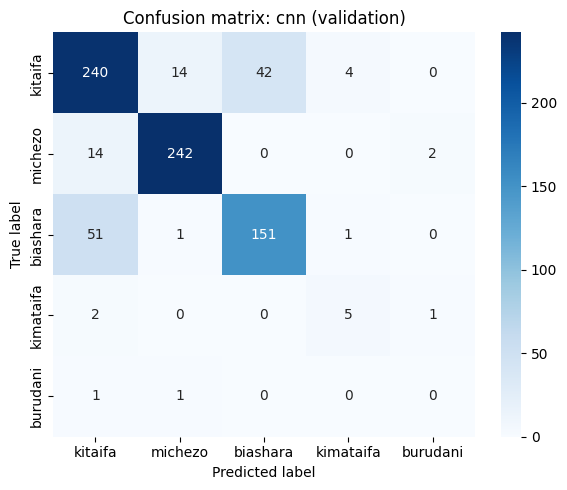

In [16]:
plots.plot_confusion_matrix(validation_ids, calibrated_validation_probabilities,
                            MODEL_NAME, "validation")

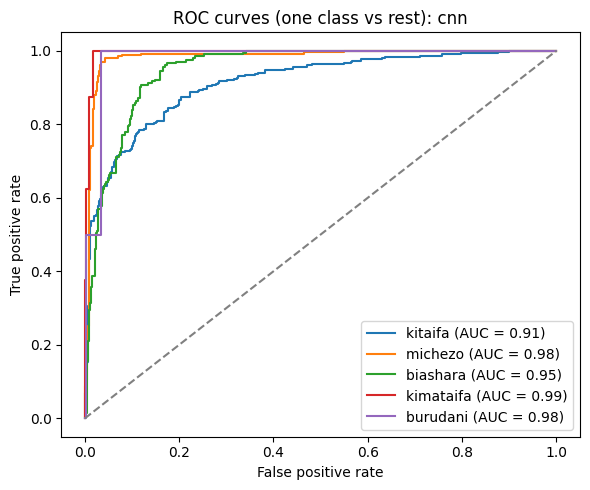

In [17]:
plots.plot_roc_curves(validation_ids, calibrated_validation_probabilities,
                      MODEL_NAME, "validation")

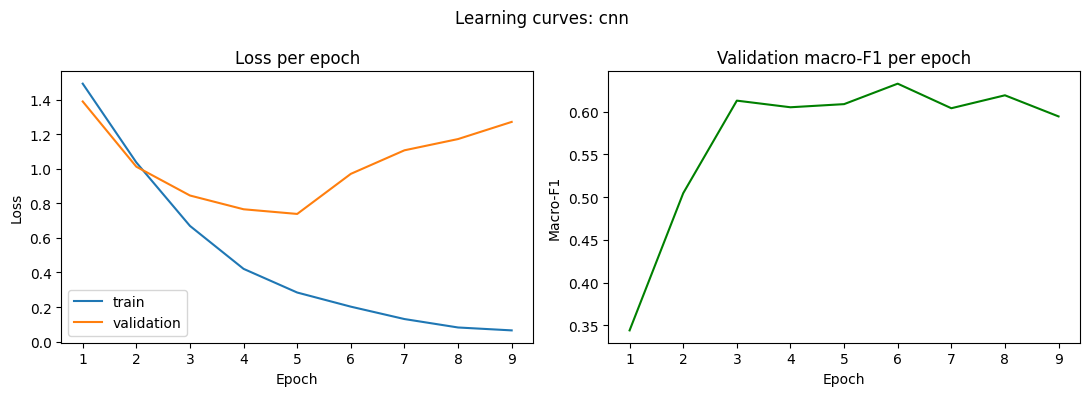

In [18]:
plots.plot_learning_curves(best["history"], MODEL_NAME)

## 5. Final evaluation on the test set

with the winning settings from section 4. The model is trained once per seed in `FINAL_RUN_SEEDS`; each run gets its own temperature (fitted on that run's validation logits) and is logged as `final_seed_<seed>`, so the report can show the mean and spread.

In [19]:
best_settings = best["settings"]
final_runs = []

for seed in FINAL_RUN_SEEDS:
    print(f"\n=== final run, seed {seed} ===")
    final_model, final_history, val_logits = train_model(best_settings, seed=seed)

    temperature = calibration.find_best_temperature(val_logits, validation_ids)
    test_logits = predict_logits(final_model, test["content"])
    test_probabilities = calibration.softmax(test_logits, temperature)

    test_scores = evaluation.compute_scores(test_ids, test_probabilities)
    evaluation.print_classification_report(test_ids, test_probabilities)
    log_experiment(MEMBER, MODEL_NAME, f"final_seed_{seed}", "test",
                   {**best_settings, "temperature": temperature}, test_scores,
                   f"Final model ({best_name}) on the test set")
    final_runs.append({"seed": seed, "model": final_model, "history": final_history,
                       "temperature": temperature, "test_scores": test_scores,
                       "test_probabilities": test_probabilities})

summary = pd.DataFrame([
    {"seed": r["seed"],
     "macro_f1": r["test_scores"]["macro_f1"],
     "log_loss": r["test_scores"]["log_loss"],
     "accuracy": r["test_scores"]["accuracy"]}
    for r in final_runs
])
print("\nMean and std over seeds:")
print(summary[["macro_f1", "log_loss", "accuracy"]].agg(["mean", "std"]))
summary


=== final run, seed 42 ===
Random seed set to 42
epoch 01 | train_loss 1.4933 | val_loss 1.3902 | val_macro_f1 0.3443
epoch 02 | train_loss 1.0372 | val_loss 1.0123 | val_macro_f1 0.5038
epoch 03 | train_loss 0.6696 | val_loss 0.8435 | val_macro_f1 0.6137
epoch 04 | train_loss 0.4214 | val_loss 0.7662 | val_macro_f1 0.6064
epoch 05 | train_loss 0.2832 | val_loss 0.7513 | val_macro_f1 0.6246
epoch 06 | train_loss 0.2024 | val_loss 0.9833 | val_macro_f1 0.5903
epoch 07 | train_loss 0.1304 | val_loss 1.1442 | val_macro_f1 0.6133
epoch 08 | train_loss 0.0806 | val_loss 1.2138 | val_macro_f1 0.6079
epoch 09 | train_loss 0.0655 | val_loss 1.3080 | val_macro_f1 0.5772
Early stopping at epoch 9
Best temperature: 1.05 (validation log loss 0.4359)
              precision    recall  f1-score   support

     kitaifa       0.86      0.78      0.82       300
     michezo       0.93      0.95      0.94       258
    biashara       0.78      0.85      0.81       204
   kimataifa       0.38      0.62 

,seed,macro_f1,log_loss,accuracy
0,42,0.6986,0.4243,0.8512
1,7,0.6820,0.4583,0.8292
2,2026,0.7010,0.4914,0.8331


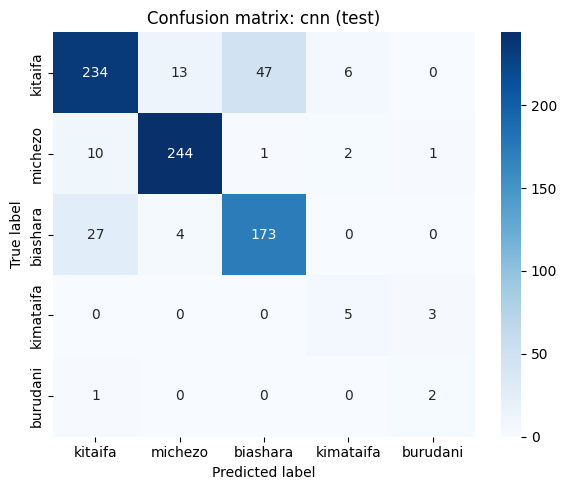

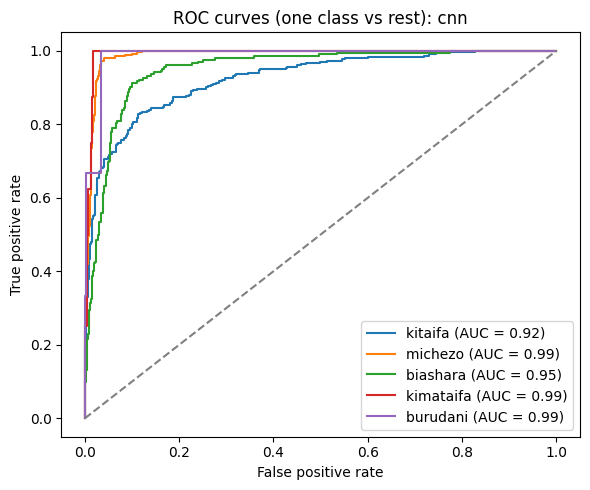

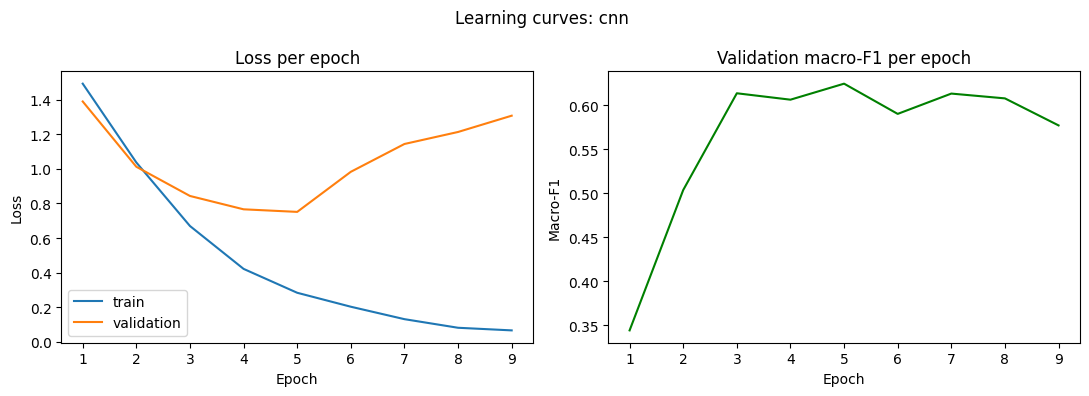

In [20]:
# figures and saved files use the median-seed run (by macro-F1) so they represent a typical run
final_runs_sorted = sorted(final_runs, key=lambda r: r["test_scores"]["macro_f1"])
typical = final_runs_sorted[len(final_runs_sorted) // 2]
final_model = typical["model"]
test_probabilities = typical["test_probabilities"]
temperature = typical["temperature"]

plots.plot_confusion_matrix(test_ids, test_probabilities, MODEL_NAME, "test")
plots.plot_roc_curves(test_ids, test_probabilities, MODEL_NAME, "test")
plots.plot_learning_curves(typical["history"], MODEL_NAME)

In [21]:
evaluation.save_misclassified_examples(test, test_ids, test_probabilities, MODEL_NAME)

Saved 115 misclassified examples to /content/nlp_language_technologies/results/misclassified/cnn.csv


In [22]:
zindi_logits = predict_logits(final_model, zindi_test["content"])
zindi_probabilities = calibration.softmax(zindi_logits, temperature)

evaluation.save_zindi_submission(zindi_test, zindi_probabilities, MODEL_NAME)

Saved Zindi submission to /content/nlp_language_technologies/results/submissions/cnn.csv


## 6. Saving the Results

Downloading the results to be added to the repository under `results/`.

In [23]:
if COLAB:
    from google.colab import files

    !zip -r results.zip results

    files.download("results.zip")

  adding: results/ (stored 0%)
  adding: results/submissions/ (stored 0%)
  adding: results/submissions/logistic regression.csv (deflated 48%)
  adding: results/submissions/transformer.csv (deflated 50%)
  adding: results/submissions/cnn.csv (deflated 49%)
  adding: results/experiment_logs/ (stored 0%)
  adding: results/experiment_logs/logistic regression.csv (deflated 82%)
  adding: results/experiment_logs/transformer.csv (deflated 86%)
  adding: results/experiment_logs/cnn.csv (deflated 84%)
  adding: results/figures/ (stored 0%)
  adding: results/figures/logistic regression/ (stored 0%)
  adding: results/figures/logistic regression/confusion_matrix_validation.png (deflated 9%)
  adding: results/figures/logistic regression/roc_curves_test.png (deflated 5%)
  adding: results/figures/logistic regression/confusion_matrix_test.png (deflated 9%)
  adding: results/figures/cnn/ (stored 0%)
  adding: results/figures/cnn/roc_curves_validation.png (deflated 11%)
  adding: results/figures/cnn/t

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>